Kevin suggested that it might be clearer what's going on if we pull the terms coupling $|0\rangle$ to $|1\rangle$ from our definition of $V$ to our definition of $H_0$.  Because these terms don't involve any interaction with the cavity, we can write (using two atoms as an example) $H_0 = H_c \otimes I_1 \otimes I_2 + I_c \otimes H^{(1)} \otimes I_2 + I_c \otimes I_1 \otimes H^{(2)}$.  This means that the eigenstates of $H_0$ are just tensor product combinations of the eigenstates of $H_c$ and $H^{(j)}$ and the eigenvalues are just sums of the eigenvalues of the states in the tensor product.  So it shouldn't be any more difficult to obtain the eigenstates for $N$ atoms as it is for 1 atom.

### Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
import qutip as qu
import sympy as sym
import itertools as it

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Main

In [3]:
# Define parameters - we'll assume for now that the coupling strengths and decay rates are uniform
g10 = 5/np.sqrt(2)
g21 = 1/np.sqrt(2)
κ = 1
γ10 = 1
γ21 = 0.05
N = 2

In [4]:
# Define the transition frequencies using a gaussian distribution
Δω = 1
rng = np.random.default_rng(seed=15)
ω21s = rng.normal(loc=5, scale=Δω, size=N) + 1j*γ21
ω10s = rng.normal(loc=2, scale=Δω, size=N) + 1j*γ10
ωc = 5 + 1j*κ

In [5]:
# Now define the operators that we'll be using
σ10 = qu.Qobj([[0, 1, 0],
               [0, 0, 0],
               [0, 0, 0]])
σ21 = qu.Qobj([[0, 0, 0],
               [0, 0, 1],
               [0, 0, 0]])
a = qu.destroy(2)

# Also define the identity operators for ease of use
Ic = qu.qeye(2)
I0 = qu.qeye(3)
I1 = qu.qeye(3)

In [6]:
# Create the cavity and atomic Hamiltonians independently
Hc = ωc * a.dag() * a
H1 = -ω10s[0] * σ10.dag() * σ10 + ω21s[0] * σ21.dag() * σ21 + g10 * (σ10.dag() + σ10)
H2 = -ω10s[1] * σ10.dag() * σ10 + ω21s[1] * σ21.dag() * σ21 + g10 * (σ10.dag() + σ10)
H1

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.        +0.j    3.53553391+0.j    0.        +0.j  ]
 [ 3.53553391+0.j   -2.39393836-1.j    0.        +0.j  ]
 [ 0.        +0.j    0.        +0.j    3.56912698+0.05j]]

In [7]:
# Now get the eigenstates
Hc_eigs = Hc.eigenstates()
H1_eigs = H1.eigenstates()
H2_eigs = H2.eigenstates()
H1_eigs

(array([-4.89951737-0.66164127j,  2.50557901-0.33835873j,
         3.56912698+0.05j      ]),
 array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.57645364+0.07784553j]
         [ 0.81341334+0.j        ]
         [-0.        +0.j        ]]                                           ,
        Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.81341334+0.j        ]
         [ 0.57645364-0.07784553j]
         [-0.        +0.j        ]]                                           ,
        Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]]                                                                ],
       dtype=object))

In [8]:
# Define H0 and get eigenstates for comparison
H0 = qu.tensor([Hc, I0, I1]) + qu.tensor([Ic, H1, I1]) + qu.tensor([Ic, I0, H2])
H0_eigs = H0.eigenstates()
H0_eigs[0]

array([-9.21591116-1.26475286j, -4.21591116-0.26475286j,
       -2.05903696-1.05852968j, -1.81081477-0.94147032j,
       -0.83606509-0.61164127j, -0.74726681-0.55311159j,
        2.94096304-0.05852968j,  3.18918523+0.05852968j,
        4.16393491+0.38835873j,  4.25273319+0.44688841j,
        5.34605943-0.73524714j,  6.40960739-0.34688841j,
        6.5690313 -0.28835873j,  7.63257926+0.1j       ,
       10.34605943+0.26475286j, 11.40960739+0.65311159j,
       11.5690313 +0.71164127j, 12.63257926+1.1j       ])

In [9]:
# Get the first eigenstate using tensor products for illustration purposes
qu.tensor(list(list(it.product(Hc_eigs[1], H1_eigs[1], H2_eigs[1]))[0])).full()

array([[ 0.35288002-0.09882483j],
       [-0.4476754 +0.06045504j],
       [-0.        +0.j        ],
       [-0.50751271+0.07091262j],
       [ 0.63169891+0.j        ],
       [ 0.        +0.j        ],
       [ 0.        -0.j        ],
       [-0.        +0.j        ],
       [-0.        +0.j        ],
       [ 0.        -0.j        ],
       [-0.        +0.j        ],
       [-0.        +0.j        ],
       [-0.        +0.j        ],
       [ 0.        +0.j        ],
       [ 0.        +0.j        ],
       [ 0.        -0.j        ],
       [-0.        +0.j        ],
       [-0.        +0.j        ]])

Now using it.product iterates the last argument first.  So the elements of the list basically count up as 000, 001, 002, 010, 011, etc..  The eigenstates of $H_0$ are returned sorted by the magnitude of the eigenvalues, so this won't match in general.  Also, this is how the tensor products of the basis vectors are generally arranged.  $|000\rangle = (1, 0, \cdots), |001\rangle = (0, 1, \cdots)$, and so on.  So we could write the first eigenstate obtained using tensor products of the individual eigenstates as $|\epsilon_c^{(0)}\rangle\otimes|\epsilon_1^{(0)}\rangle\otimes|\epsilon_2^{(0)}\rangle = \alpha|000\rangle + \beta|001\rangle + \gamma|010\rangle + \delta|011\rangle$.

In [10]:
# Check that we get the same eigenvalues as for H0
np.allclose(np.sort([np.sum(_) for _ in list(it.product(Hc_eigs[0], H1_eigs[0], H2_eigs[0]))]), H0_eigs[0])

True

Now that we've confirmed that the eigenvalues and eigenstates of $H_0$ can be obtained as we expect, we can move on to calculating the level shift function for some of these eigenstates.  For our two atom system here, we can just iterate over the eigenstates and do the matrix multiplication, but for larger systems we'll want to have another approach that scales better.  These results will then serve as a useful check.

In [11]:
def two_term_Rx(z, x, V, H0_eigs):
    """
    Function for calculating the level shift function up to two terms
    :param z:       the complex argument for the level shift function
    :param x:       the eigenstate to calculate the level shift function for
    :param V:       the interaction to use in calculating the level shift function
    :param H0_eigs: the eigenstates and eigenenergies of the unperturbed Hamiltonian
    :returns:       the level shift function
    """
    # First we need to use a masked array to remove x from the possible eigenstates that we'll sum over
    # Get the index in H0_eigs to exclude
    temp = np.array([x])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the masked array
    mask = np.ones(H0_eigs[1][0].shape[0], dtype=bool)

    # Eliminate the unwanted index in the masked array
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues of H0
    masked_vals = H0_eigs[0][mask]
    masked_states = H0_eigs[1][mask]

    # Now calculate the level shift function
    Rx = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * x

    return Rx

In [12]:
def three_term_Rx(z, x, V, H0_eigs):
    # First we need to use a masked array to remove x from the possible eigenstates that we'll sum over
    # Get the index in H0_eigs to exclude
    temp = np.array([x])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the masked array
    mask = np.ones(H0_eigs[1][0].shape[0], dtype=bool)

    # Eliminate the unwanted index in the masked array
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues of H0
    masked_vals = H0_eigs[0][mask]
    masked_states = H0_eigs[1][mask]

    # Now calculate the level shift function
    Rx = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * x

    return Rx

In [13]:
def four_term_Rx(z, x, V, H0_eigs):
    # First we need to use a masked array to remove x from the possible eigenstates that we'll sum over
    # Get the index in H0_eigs to exclude
    temp = np.array([x])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the masked array
    mask = np.ones(H0_eigs[1][0].shape[0], dtype=bool)

    # Eliminate the unwanted index in the masked array
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues of H0
    masked_vals = H0_eigs[0][mask]
    masked_states = H0_eigs[1][mask]

    # Now calculate the level shift function
    Rx = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                for Eq, q in zip(masked_vals, masked_states):
                    Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * q * 1 / (z[i] - Eq) * q.dag() * V * x

    return Rx

In [14]:
def six_term_Rx(z, x, V, H0_eigs):
    # First we need to use a masked array to remove x from the possible eigenstates that we'll sum over
    # Get the index in H0_eigs to exclude
    temp = np.array([x])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the masked array
    mask = np.ones(H0_eigs[1][0].shape[0], dtype=bool)

    # Eliminate the unwanted index in the masked array
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues of H0
    masked_vals = H0_eigs[0][mask]
    masked_states = H0_eigs[1][mask]

    # Now calculate the level shift function
    Rx = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                for Eq, q in zip(masked_vals, masked_states):
                    Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * q * 1 / (z[i] - Eq) * q.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                for Eq, q in zip(masked_vals, masked_states):
                    for Ek, k in zip(masked_vals, masked_states):
                        for El, l in zip(masked_vals, masked_states):
                            temp = x.dag() * V * y * 1 / (z[i] - Ey)
                            temp *= y.dag() * V * p * 1 / (z[i] - Ep)
                            temp *= p.dag() * V * q * 1 / (z[i] - Eq)
                            temp *= q.dag() * V * k * 1 / (z[i] - Ek)
                            temp *= k.dag() * V * l * 1 / (z[i] - El)
                            temp *= l.dag() * V * x
                            Rx[i] += temp

    return Rx

In [15]:
def transfer_func(z, R, Ex):
    """
    Function for evaluating the transfer function from the level shift function
    :param z:  the complex argument that the function varies with
    :param R:  the level shift function values
    :param Ex: the eigenvalue of the eigenstate used in calculating the level shift function
    :returns:  the values of the transfer function
    """
    return 1 / (z - Ex - R)

In [16]:
# Define V
V = g21 * (qu.tensor([a, σ21.dag(), I1]) + qu.tensor([a.dag(), σ21, I1]))
V += g21 * (qu.tensor([a, I0, σ21.dag()]) + qu.tensor([a.dag(), I0, σ21]))

In [17]:
# Define ω range
ω = np.linspace(-50, 50, 500)

In [18]:
# Calculate Rx for some choices of x
R0 = two_term_Rx(ω, H0_eigs[1][0], V, H0_eigs)
R1 = two_term_Rx(ω, H0_eigs[1][1], V, H0_eigs)
R7 = two_term_Rx(ω, H0_eigs[1][7], V, H0_eigs)
R16 = two_term_Rx(ω, H0_eigs[1][16], V, H0_eigs)

/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


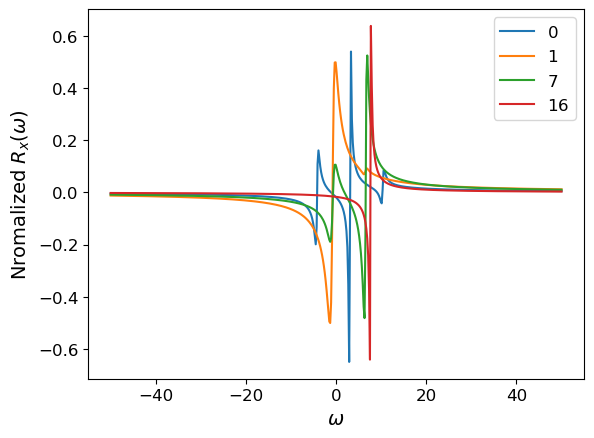

In [19]:
# Plot the level shift functions
plt.plot(ω, R0 / np.max(np.abs(R0)), label='$0$')
plt.plot(ω, R1 / np.max(np.abs(R1)), label='$1$')
plt.plot(ω, R7 / np.max(np.abs(R7)), label='$7$')
plt.plot(ω, R16 / np.max(np.abs(R16)), label='$16$')
plt.xlabel("$\\omega$")
plt.ylabel("Nromalized $R_{x}(\\omega)$")
plt.legend()

In [20]:
# Calculate the corresponding transfer functions
K0 = transfer_func(ω, H0_eigs[0][0], R0)
K1 = transfer_func(ω, H0_eigs[0][1], R1)
K7 = transfer_func(ω, H0_eigs[0][7], R7)
K16 = transfer_func(ω, H0_eigs[0][16], R16)

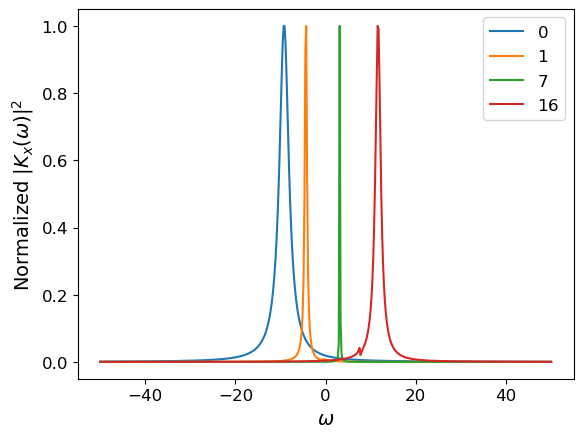

In [21]:
# Plot abs(Kx) ** 2
plt.plot(ω, np.abs(K0) ** 2 / np.max(np.abs(K0) ** 2), label='$0$')
plt.plot(ω, np.abs(K1) ** 2 / np.max(np.abs(K1) ** 2), label='$1$')
plt.plot(ω, np.abs(K7) ** 2 / np.max(np.abs(K7) ** 2), label='$7$')
plt.plot(ω, np.abs(K16) ** 2 / np.max(np.abs(K16) ** 2), label='$16$')
plt.xlabel("$\\omega$")
plt.ylabel("Normalized $|K_{x}(\\omega)|^2$")
plt.legend()

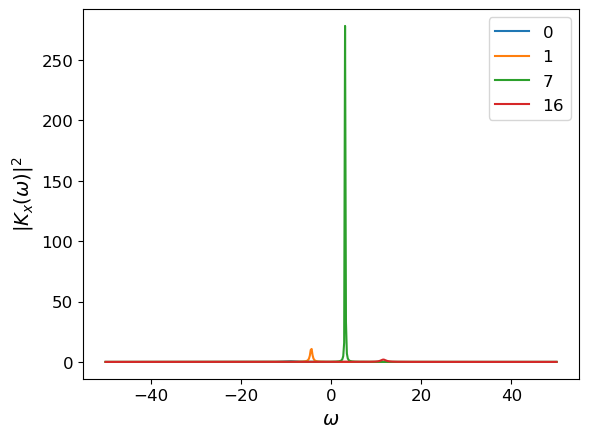

In [22]:
# Plot abs(Kx) ** 2
plt.plot(ω, np.abs(K0) ** 2, label='$0$')
plt.plot(ω, np.abs(K1) ** 2, label='$1$')
plt.plot(ω, np.abs(K7) ** 2, label='$7$')
plt.plot(ω, np.abs(K16) ** 2, label='$16$')
plt.xlabel("$\\omega$")
plt.ylabel("$|K_{x}(\\omega)|^2$")
plt.legend()

Now let's compare the values we get here to those obtained using more terms in Rx.

In [23]:
# Calculate the three term level shift functions
R0_3 = three_term_Rx(ω, H0_eigs[1][0], V, H0_eigs)
R1_3 = three_term_Rx(ω, H0_eigs[1][1], V, H0_eigs)
R7_3 = three_term_Rx(ω, H0_eigs[1][7], V, H0_eigs)
R16_3 = three_term_Rx(ω, H0_eigs[1][16], V, H0_eigs)

In [24]:
# Calculate the 4 term level shift functions
R0_4 = four_term_Rx(ω, H0_eigs[1][0], V, H0_eigs)
R1_4 = four_term_Rx(ω, H0_eigs[1][1], V, H0_eigs)
R7_4 = four_term_Rx(ω, H0_eigs[1][7], V, H0_eigs)
R16_4 = four_term_Rx(ω, H0_eigs[1][16], V, H0_eigs)

In [25]:
# Calculate the 6 term level shift functions
#R0_6 = six_term_Rx(ω, H0_eigs[1][0], V, H0_eigs)
#R1_6 = six_term_Rx(ω, H0_eigs[1][1], V, H0_eigs)
#R7_6 = six_term_Rx(ω, H0_eigs[1][7], V, H0_eigs)
#R16_6 = six_term_Rx(ω, H0_eigs[1][16], V, H0_eigs)

Text(0.5, 1.0, '$x=16$')

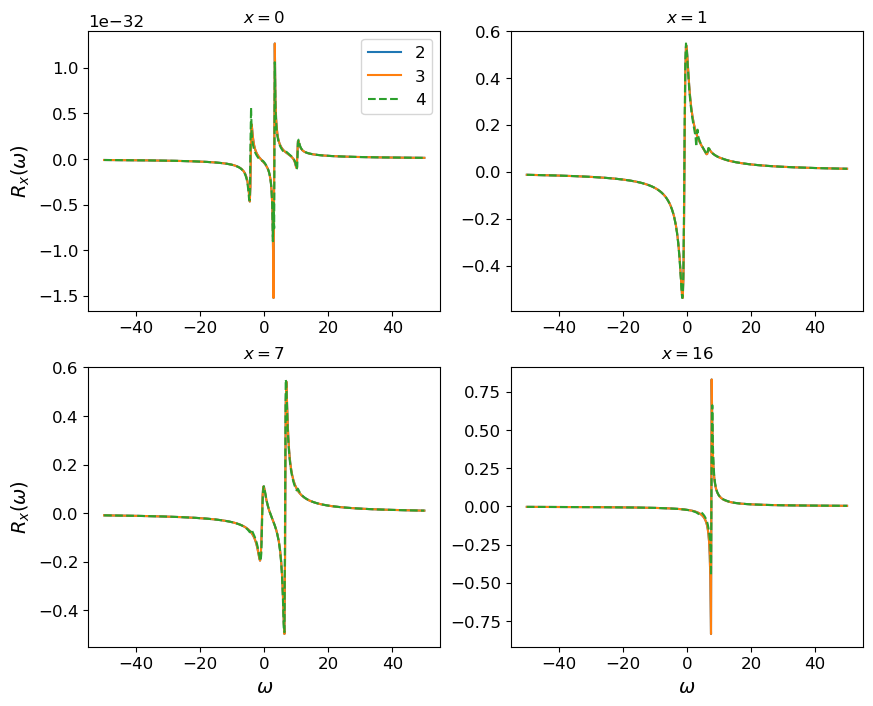

In [26]:
fig = plt.figure(1,figsize=(10,8))
ax = fig.subplots(2,2)
ax[0][0].plot(ω, R0, label='2')
ax[0][0].plot(ω, R0_3, label='3')
ax[0][0].plot(ω, R0_4, '--', label='4')
#ax[0][0].plot(ω, R0_6, '--', label='6')
ax[0][0].set_ylabel("$R_x(\\omega)$")
ax[0][0].set_title("$x=0$")
ax[0][0].legend()

ax[0][1].plot(ω, R1, label='2')
ax[0][1].plot(ω, R1_3, label='3')
ax[0][1].plot(ω, R1_4, '--', label='4')
#ax[0][1].plot(ω, R1_6, '--', label='6')
ax[0][1].set_title("$x=1$")

ax[1][0].plot(ω, R7, label='2')
ax[1][0].plot(ω, R7_3, label='3')
ax[1][0].plot(ω, R7_4, '--', label='4')
#ax[1][0].plot(ω, R7_6, '--', label='6')
ax[1][0].set_xlabel("$\\omega$")
ax[1][0].set_ylabel("$R_x(\\omega)$")
ax[1][0].set_title("$x=7$")

ax[1][1].plot(ω, R16, label='2')
ax[1][1].plot(ω, R16_3, label='3')
ax[1][1].plot(ω, R16_4, '--', label='4')
#ax[1][1].plot(ω, R16_6, '--', label='6')
ax[1][1].set_xlabel("$\\omega$")
ax[1][1].set_title("$x=16$")

In [28]:
# Calculate the corresponding transfer functions
K0_3 = transfer_func(ω, H0_eigs[0][0], R0_3)
K1_3 = transfer_func(ω, H0_eigs[0][1], R1_3)
K7_3 = transfer_func(ω, H0_eigs[0][7], R7_3)
K16_3 = transfer_func(ω, H0_eigs[0][16], R16_3)

K0_4 = transfer_func(ω, H0_eigs[0][0], R0_4)
K1_4 = transfer_func(ω, H0_eigs[0][1], R1_4)
K7_4 = transfer_func(ω, H0_eigs[0][7], R7_4)
K16_4 = transfer_func(ω, H0_eigs[0][16], R16_4)

#K0_6 = transfer_func(ω, H0_eigs[0][0], R0_6)
#K1_6 = transfer_func(ω, H0_eigs[0][1], R1_6)
#K7_6 = transfer_func(ω, H0_eigs[0][7], R7_6)
#K16_6 = transfer_func(ω, H0_eigs[0][16], R16_6)

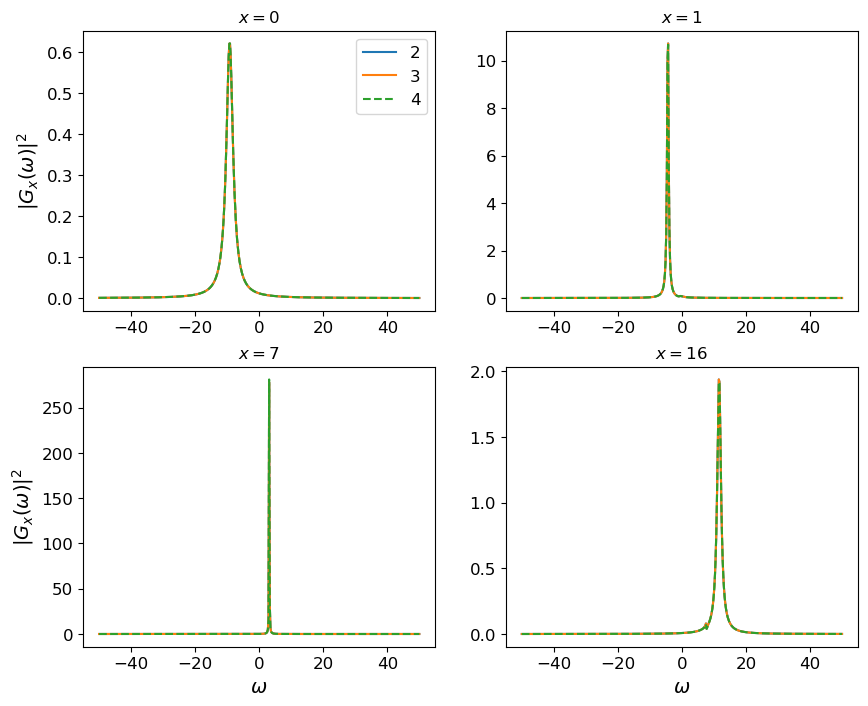

In [35]:
fig = plt.figure(1,figsize=(10,8))
ax = fig.subplots(2,2)
ax[0][0].plot(ω, np.abs(K0) ** 2, label='2')
ax[0][0].plot(ω, np.abs(K0_3) ** 2, label='3')
ax[0][0].plot(ω, np.abs(K0_4) ** 2, '--', label='4')
#ax[0][0].plot(ω, np.abs(K0_6) ** 2, label='6')
ax[0][0].set_ylabel("$|G_x(\\omega)|^2$")
ax[0][0].set_title("$x=0$")
ax[0][0].legend()

ax[0][1].plot(ω, np.abs(K1) ** 2, label='2')
ax[0][1].plot(ω, np.abs(K1_3) ** 2, label='3')
ax[0][1].plot(ω, np.abs(K1_4) ** 2, '--', label='4')
#ax[0][1].plot(ω, np.abs(K1_6) ** 2, label='6')
ax[0][1].set_title("$x=1$")

ax[1][0].plot(ω, np.abs(K7) ** 2, label='2')
ax[1][0].plot(ω, np.abs(K7_3) ** 2, label='3')
ax[1][0].plot(ω, np.abs(K7_4) ** 2, '--', label='4')
#ax[1][0].plot(ω, np.abs(K7_6) ** 2, label='6')
ax[1][0].set_xlabel("$\\omega$")
ax[1][0].set_ylabel("$|G_x(\\omega)|^2$")
ax[1][0].set_title("$x=7$")

ax[1][1].plot(ω, np.abs(K16) ** 2, label='2')
ax[1][1].plot(ω, np.abs(K16_3) ** 2, label='3')
ax[1][1].plot(ω, np.abs(K16_4) ** 2, '--', label='4')
#ax[1][1].plot(ω, np.abs(K16_6) ** 2, label='6')
ax[1][1].set_xlabel("$\\omega$")
ax[1][1].set_title("$x=16$")
plt.savefig("abs_val_Gx.png", dpi=300, format='png')

In [30]:
# Let's calculate the errors
err0_3 = np.abs(np.abs(K0) ** 2 - np.abs(K0_3) ** 2) / np.abs(K0) ** 2
err0_4 = np.abs(np.abs(K0) ** 2 - np.abs(K0_4) ** 2) / np.abs(K0) ** 2
#err0_6 = np.abs(np.abs(K0) ** 2 - np.abs(K0_6) ** 2) / np.abs(K0) ** 2

err1_3 = np.abs(np.abs(K1) ** 2 - np.abs(K1_3) ** 2) / np.abs(K1) ** 2
err1_4 = np.abs(np.abs(K1) ** 2 - np.abs(K1_4) ** 2) / np.abs(K1) ** 2
#err1_6 = np.abs(np.abs(K1) ** 2 - np.abs(K1_6) ** 2) / np.abs(K1) ** 2

err7_3 = np.abs(np.abs(K7) ** 2 - np.abs(K7_3) ** 2) / np.abs(K7) ** 2
err7_4 = np.abs(np.abs(K7) ** 2 - np.abs(K7_4) ** 2) / np.abs(K7) ** 2
#err7_6 = np.abs(np.abs(K7) ** 2 - np.abs(K7_6) ** 2) / np.abs(K7) ** 2

err16_3 = np.abs(np.abs(K16) ** 2 - np.abs(K16_3) ** 2) / np.abs(K16) ** 2
err16_4 = np.abs(np.abs(K16) ** 2 - np.abs(K16_4) ** 2) / np.abs(K16) ** 2
#err16_6 = np.abs(np.abs(K16) ** 2 - np.abs(K16_6) ** 2) / np.abs(K16) ** 2

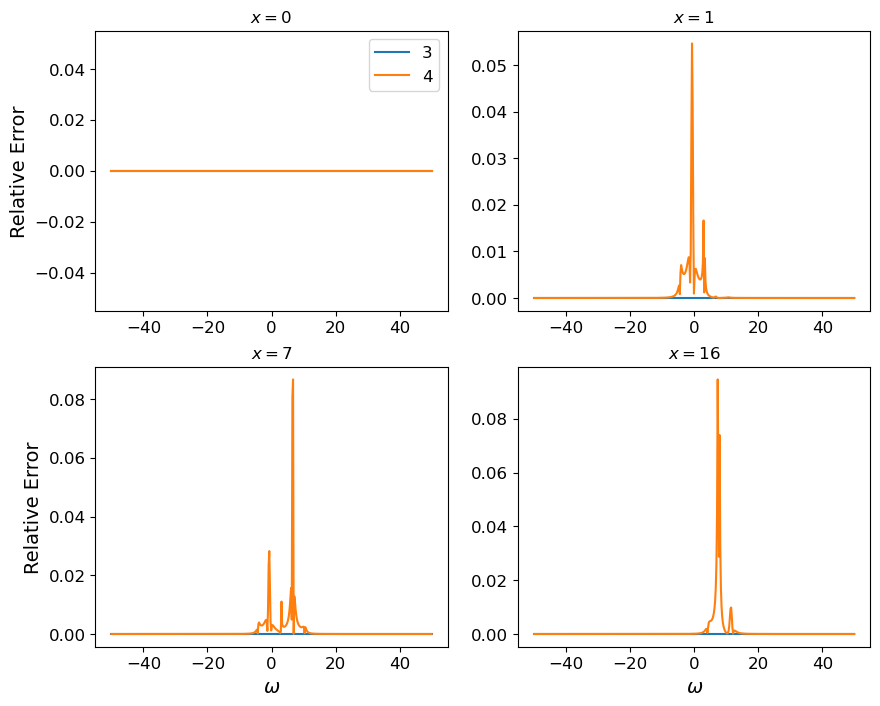

In [34]:
fig = plt.figure(1,figsize=(10,8))
ax = fig.subplots(2,2)
ax[0][0].plot(ω, err0_3, label='3')
ax[0][0].plot(ω, err0_4, label='4')
#ax[0][0].plot(ω, err0_6, label='6')
ax[0][0].set_ylabel("Relative Error")
ax[0][0].set_title("$x=0$")
ax[0][0].legend()

ax[0][1].plot(ω, err1_3, label='3')
ax[0][1].plot(ω, err1_4, label='4')
#ax[0][1].plot(ω, err1_6, label='6')
ax[0][1].set_title("$x=1$")

ax[1][0].plot(ω, err7_3, label='3')
ax[1][0].plot(ω, err7_4, label='4')
#ax[1][0].plot(ω, err7_6, label='6')
ax[1][0].set_xlabel("$\\omega$")
ax[1][0].set_ylabel("Relative Error")
ax[1][0].set_title("$x=7$")

ax[1][1].plot(ω, err16_3, label='3')
ax[1][1].plot(ω, err16_4, label='4')
#ax[1][1].plot(ω, err16_6, label='4')
ax[1][1].set_xlabel("$\\omega$")
ax[1][1].set_title("$x=16$")
plt.savefig("rel_err_in_Gx.png", dpi=300, format='png')